In [ ]:
Warehouses = {'w1', 'w2', 'w3'}
Retailers = {'r1', 'r2', 'r3', 'r4'}
Cost = {
    ('w1', 'r1') : 7, 	('w1', 'r2') : 3, 	('w1', 'r3') : 8, 	('w1', 'r4') : 4, 
    ('w2', 'r1') : 9, 	('w2', 'r2') : 5, 	('w2', 'r3') : 6, 	('w2', 'r4') : 3, 
    ('w3', 'r1') : 4, 	('w3', 'r2') : 6, 	('w3', 'r3') : 9, 	('w3', 'r4') : 6
}
Supply = { 'w1' : 6000, 'w2' : 9000, 'w3' : 4000 }
Demand = { 'r1' : 3900, 'r2' : 5200, 'r3' : 2700, 'r4' : 6400 }

### CleanCo – Transportation Optimization Model Summary

### Sets
- \( W \): Warehouses  
- \( R \): Retail Outlets

### Parameters
- \( s_w \): Supply at warehouse \( w \)  
- \( d_r \): Demand at outlet \( r \)  
- \( c_{wr} \): Cost to ship from warehouse \( w \) to outlet \( r \)

### Decision Variables
- \( x_{wr} \): Units shipped from warehouse \( w \) to outlet \( r \)

### Objective
- Minimize total shipping cost:  
  \[
  \min \sum_{w \in W} \sum_{r \in R} c_{wr} x_{wr}
  \]

### Constraints
- Supply limits:  
  \[
  \sum_{r \in R} x_{wr} \leq s_w \quad \forall w \in W
  \]
- Demand fulfillment:  
  \[
  \sum_{w \in W} x_{wr} \geq d_r \quad \forall r \in R
  \]
- Non-negativity: \( x_{wr} \geq 0 \)

### Solver Output
Optimal solution found \& Total Shipping Cost is \$$66,700 and Total Units Shipped is 18,200.

In [2]:
import gurobipy as gp
from gurobipy import GRB

# Sets
Warehouses = ['W1', 'W2', 'W3']
Outlets = ['R1', 'R2', 'R3', 'R4']

# Parameters
Supply = {'W1': 6000, 'W2': 9000, 'W3': 4000}
Demand = {'R1': 3900, 'R2': 5200, 'R3': 2700, 'R4': 6400}

# Costs (cost per unit from warehouse to outlet)
Cost = {
    ('W1', 'R1'): 7, ('W1', 'R2'): 3, ('W1', 'R3'): 8, ('W1', 'R4'): 4,
    ('W2', 'R1'): 9, ('W2', 'R2'): 5, ('W2', 'R3'): 6, ('W2', 'R4'): 3,
    ('W3', 'R1'): 4, ('W3', 'R2'): 6, ('W3', 'R3'): 9, ('W3', 'R4'): 6
}

# Model
model = gp.Model("CleanCo_Transportation")

# Decision Variables: x[w, r] = units shipped from warehouse w to outlet r
x = model.addVars(Warehouses, Outlets, name="x", lb=0.0)

# Objective: Minimize total shipping cost
model.setObjective(gp.quicksum(Cost[w, r] * x[w, r] for w in Warehouses for r in Outlets), GRB.MINIMIZE)

# Constraints
# Supply: cannot ship more than what's available
for w in Warehouses:
    model.addConstr(gp.quicksum(x[w, r] for r in Outlets) <= Supply[w], name=f"Supply_{w}")

# Demand: must meet or exceed each outlet's demand
for r in Outlets:
    model.addConstr(gp.quicksum(x[w, r] for w in Warehouses) >= Demand[r], name=f"Demand_{r}")

# Optimize
model.optimize()

# Output Results
print("\nOptimal Shipping Plan:")
for w in Warehouses:
    for r in Outlets:
        if x[w, r].X > 1e-6:
            print(f"  Ship {x[w, r].X:.0f} units from {w} to {r}")
print(f"\nTotal Shipping Cost: ${model.ObjVal:,.2f}")

# Sanity Checks
assert model.status == GRB.OPTIMAL, "Model did not solve to optimality!"
for (w, r) in x:
    assert x[w, r].X >= 0, f"Negative shipment from {w} to {r}"

total_supplied = sum(x[w, r].X for w in Warehouses for r in Outlets)
total_demand = sum(Demand[r] for r in Outlets)
print(f"\nTotal units shipped: {total_supplied:.0f}, Total demand: {total_demand}")
assert abs(total_supplied - total_demand) < 1e-6

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Max
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 7 rows, 12 columns and 24 nonzeros
Model fingerprint: 0x2f2a5a1f
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+00, 9e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+03, 9e+03]
Presolve time: 0.00s
Presolved: 7 rows, 12 columns, 24 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.820000e+04   0.000000e+00      0s
       5    6.6700000e+04   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.00 seconds (0.00 work units)
Optimal objective  6.670000000e+04

Optimal Shipping Plan:
  Ship 5200 units from W1 to R2
  Ship 100 units from W1 to R4
  Ship 2700 units from W2 to R3
  Ship 6300 units from W2 to R4
  Ship 3900 units from W3 to R1

Total Shipping Cost: $66,700

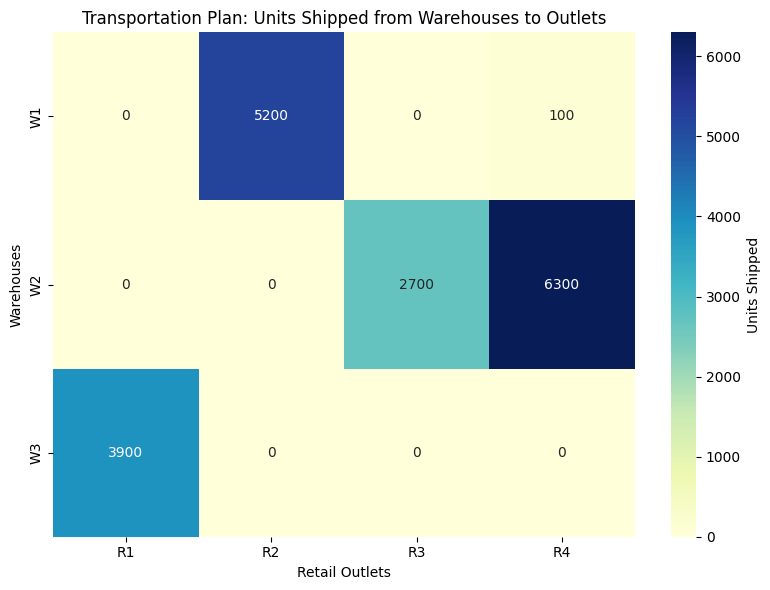

In [5]:
## Optional Result Visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = [
    {"Warehouse": w, "Outlet": r, "Quantity": x[w, r].X, "Cost": Cost[w, r]}
    for w in Warehouses for r in Outlets if x[w, r].X > 1e-6
]
df = pd.DataFrame(results)
df["Total Cost"] = df["Quantity"] * df["Cost"]
df.to_csv("cleanco_solution.csv", index=False)

# Prepare shipping matrix
flow_matrix = pd.DataFrame(index=Warehouses, columns=Outlets)

for w in Warehouses:
    for r in Outlets:
        flow_matrix.loc[w, r] = x[w, r].X if x[w, r].X > 1e-6 else 0

flow_matrix = flow_matrix.astype(float)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(flow_matrix, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Units Shipped'})
plt.title("Transportation Plan: Units Shipped from Warehouses to Outlets")
plt.ylabel("Warehouses")
plt.xlabel("Retail Outlets")
plt.tight_layout()
plt.show()
